# Use Case for KNN: Predict diabetes
Objective: Predict whether a person will be diagnosed with diabetes or not

In [2]:
pip install kagglehub


Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Step 1: Download latest version
path = kagglehub.dataset_download("whenamancodes/predict-diabities")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 8.91k/8.91k [00:00<00:00, 3.01MB/s]

Extracting files...
Path to dataset files: C:\Users\Dell\.cache\kagglehub\datasets\whenamancodes\predict-diabities\versions\1


In [6]:
import pandas as pd
import os
# Step 2: Check the contents of the downloaded folder
print("Files in dataset folder:", os.listdir(path))

# Step 3: Load the CSV file into a DataFrame
# Replace 'diabetes.csv' with the actual filename from os.listdir(path)
file_name = 'diabetes.csv'  
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

# Step 4: Display the dataset
print(df.head())  # shows the first 5 rows

Files in dataset folder: ['diabetes.csv']
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [8]:
df.shape

(768, 9)

In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [15]:
# replace zeros
zero_not_accepted = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in zero_not_accepted:
    df[column] = df[column].replace(0, np.nan)
    mean = int(df[column].mean(skipna=True))
    df[column] = df[column].replace(np.nan, mean)

In [16]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.000000,768.000000
mean,4.423177,121.682292,72.386719,29.108073,155.28125,32.450911,0.471876,33.240885,0.348958
std,2.980481,30.435999,12.096642,8.791221,85.02155,6.875366,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.00000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,25.000000,121.50000,27.500000,0.243750,24.000000,0.000000
50%,4.000000,117.000000,72.000000,29.000000,155.00000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.00000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.00000,67.100000,2.420000,81.000000,1.000000


In [17]:
# split dataset
x = df.iloc[:, 0:8]
y = df.iloc[:, 8]
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0, test_size=0.2) 

In [18]:
# feature scaling
sc_x = StandardScaler()
x_train  = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [19]:
import math
math.sqrt(len(y_test))

12.409673645990857

In [20]:
# define the model
classifier = KNeighborsClassifier(n_neighbors=11, p=2,metric='euclidean')

In [21]:
# fit the model
classifier.fit(x_train, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [23]:
# predict the test set results
y_pred = classifier.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
# model evaluation
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[94 13]
 [17 30]]


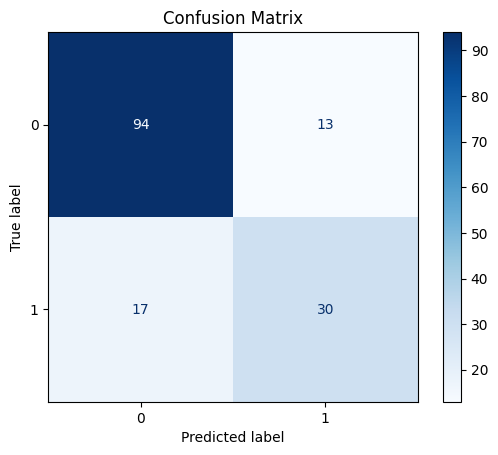

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [28]:
print(f1_score(y_test,y_pred))

0.6666666666666666


In [29]:
print(accuracy_score(y_test,y_pred))

0.8051948051948052


In [31]:
import joblib
filename = "diabetes_KNN_prediction_model.pkl"

#saving the model
joblib.dump(classifier, filename)
print(f"Model saved successfully as '{filename}'")

Model saved successfully as 'diabetes_KNN_prediction_model.pkl'


In [32]:
import joblib

#loading the model
model = joblib.load("diabetes_KNN_prediction_model.pkl")
print("Model loaded successfully")

Model loaded successfully


In [33]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])